# CSC420 Assignment 4 - implementation
## Zixuan Zeng 1008533419

# Imports

In [1]:
# import
import os

import cv2
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


# Question 4: Homography

## 4.1 case setup:

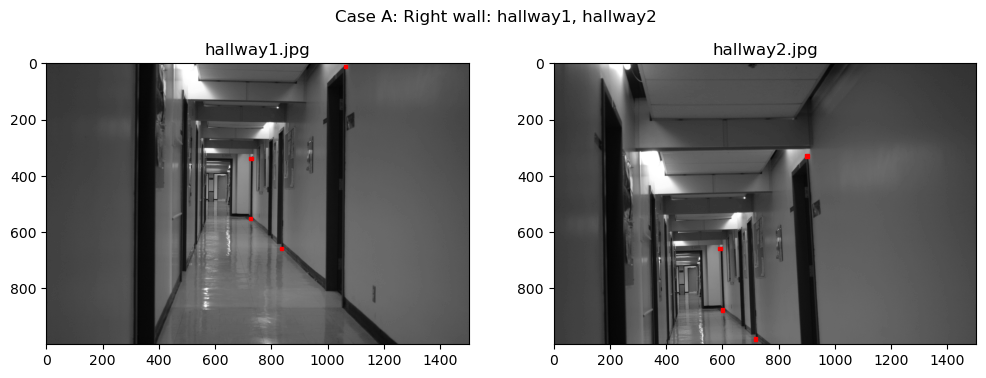

In [2]:
# Change to 'B' or 'C' as needed
# rerun entire Question 4 after change
case = 'A'  

if case == 'A':
    case_description = "Right wall: hallway1, hallway2"
    img1_path = 'hallway1.jpg'  # I1
    img2_path = 'hallway2.jpg'  # I2
    pts1 = np.array([[727.17975096, 337.84330464],
                    [1062.7991877, 11.95196751],
                    [837.10727662, 659.84340192],
                    [726.206941, 552.83430614]], dtype=float)
    pts2 = np.array([[590.98635634, 657.89778199],
                    [901.31273408, 330.06082494],
                    [718.42446131, 980.87068924],
                    [599.74164599, 877.75283331]], dtype=float)
elif case == 'B':
    case_description = "Right wall: hallway1, hallway3"
    img1_path = 'hallway1.jpg'
    img2_path = 'hallway3.jpg'
    pts1 = np.array([[729.12537088, 340.76173452],
                    [1059.88075782, 12.92477747],
                    [1095.8747264, 228.88858894],
                    [1161.05299382, 793.11836665],
                    [992.75687047, 767.82530765],
                    [838.08008658, 658.87059195],
                    [726.206941, 554.77992607]], dtype=float)
    pts2 = np.array([[753.44561992, 534.35091687],
                    [934.38827278, 204.5683399],
                    [964.54538158, 417.61372148],
                    [1021.94116932, 985.73473904],
                    [918.82331339, 959.46887008],
                    [824.46074712, 852.45977431],
                    [756.36404981, 746.4234885]], dtype=float)
elif case == 'C':
    case_description = "Floor: hallway1, hallway3"
    img1_path = 'hallway1.jpg'
    img2_path = 'hallway3.jpg'
    pts1 = np.array([[609.46974561, 487.65603872],
                    [655.1918138, 545.05182645],
                    [718.42446131, 546.99744637],
                    [788.46677854, 613.14852376],
                    [821.54231723, 642.33282261],
                    [995.67530036, 812.57456588],
                    [497.59660003, 741.55943869],
                    [536.50899849, 644.27844253]], dtype=float)
    pts2 = np.array([[666.86553334, 682.21803103],
                    [688.2673525, 740.58662873],
                    [750.52719004, 741.55943869],
                    [794.30363831, 806.73770611],
                    [814.7326475, 836.89481492],
                    [919.79612335, 999.35407851],
                    [446.03767207, 944.87672066],
                    [526.78089888, 844.67729462]], dtype=float)


def rgb2gray(rgb):
    return 0.2989*rgb[...,0] + 0.5870*rgb[...,1] + 0.1140*rgb[...,2]
# load images
I1_rgb = np.array(Image.open(img1_path)).astype(float) / 255.0
I2_rgb = np.array(Image.open(img2_path)).astype(float) / 255.0
# grayscale
I1_gray = rgb2gray(I1_rgb)
I2_gray = rgb2gray(I2_rgb)
# shapes
h1, w1 = I1_gray.shape
h2, w2 = I2_gray.shape
N = pts1.shape[0]


# show selected points
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].imshow(I1_gray, cmap='gray')
ax[0].set_title(img1_path)
for i in range(N):
    x, y = pts1[i]
    rect = patches.Rectangle((x-6, y-6), 12, 12, linewidth=1,
                             edgecolor='red', facecolor='red')
    ax[0].add_patch(rect)

ax[1].imshow(I2_gray, cmap='gray')
ax[1].set_title(img2_path)
for i in range(N):
    x, y = pts2[i]
    rect = patches.Rectangle((x-6, y-6), 12, 12, linewidth=1,
                             edgecolor='red', facecolor='red')
    ax[1].add_patch(rect)

plt.suptitle(f"Case {case}: {case_description}\n")
plt.show()

## 4.2 fitting homography

In [3]:
def compute_Homography(pts1, pts2):
    # Compute the 3x3 homography matrix H
    # DLT
    N = pts1.shape[0]
    A = []
    for i in range(N):
        x, y = pts1[i,0], pts1[i,1]
        xp, yp = pts2[i,0], pts2[i,1]
        A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y, -xp])
        A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y, -yp])

    # concatenate
    A = np.array(A)
    # SVD
    U, S, Vt = np.linalg.svd(A)
    # homography is the last column of V
    h = Vt[-1, :]
    H = h.reshape(3, 3)
    # normalization ?divide by 0
    H = H / H[2,2]
    return H

H = compute_Homography(pts1, pts2)
print("Estimated Homography (H) =\n", H)

Estimated Homography (H) =
 [[ 1.11418672e+00  6.45826835e-03 -1.95425538e+02]
 [ 1.07535227e-02  1.00748626e+00  3.38631466e+02]
 [ 9.21056763e-05 -6.81090744e-05  1.00000000e+00]]


## 4.3 mapping via homography

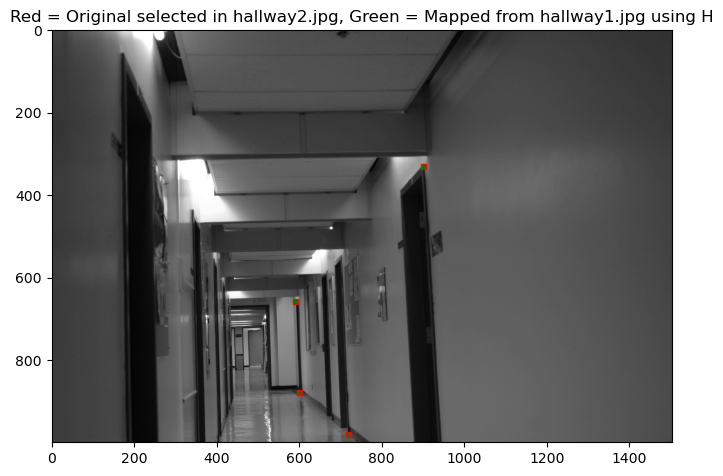

In [4]:
def apply_Homography(H, x, y):
    vec = np.array([x, y, 1.0])
    out = H @ vec
    if abs(out[2]) > 1e-8:
        out = out / out[2]
    return out[0], out[1]

mapped_pts = []
for i in range(N):
    mx, my = apply_Homography(H, pts1[i,0], pts1[i,1])
    mapped_pts.append([mx, my])
mapped_pts = np.array(mapped_pts)

# plot mapping: red=ground truth, green=mapped
plt.figure(figsize=(8,6))
plt.imshow(I2_gray, cmap='gray')
plt.title(f"Red = Original selected in {img2_path}, Green = Mapped from {img1_path} using H")

# ground truth points in red
for i in range(N):
    x, y = pts2[i]
    rect = patches.Rectangle((x-6, y-6), 12, 12, linewidth=1,
                             edgecolor='red', facecolor='red')
    plt.gca().add_patch(rect)
# mapped points in green
for i in range(N):
    x, y = mapped_pts[i]
    rect = patches.Rectangle((x-3, y-3), 6, 6, linewidth=1,
                             edgecolor='green', facecolor='green')
    plt.gca().add_patch(rect)

plt.show()

## 4.4 merging images

image size:  1782 1356


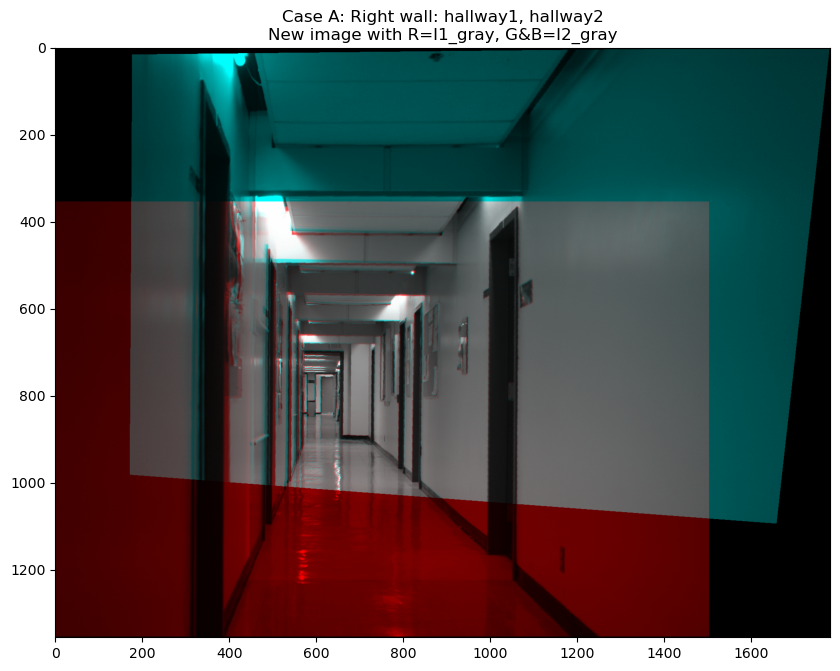

In [5]:
# find bounding box for new image
# corners of I and I' to find bounding box.
corners_I1 = np.array([[0,0],[w1,0],[w1,h1],[0,h1]], dtype=float)
corners_I2 = np.array([[0,0],[w2,0],[w2,h2],[0,h2]], dtype=float)

# Function to map corners using H
def map_corners(corners, H):
    mapped = []
    for c in corners:
        mx, my = apply_Homography(H, c[0], c[1])
        mapped.append([mx, my])
    return np.array(mapped)

# map I2 to I1: inverse H
H_inv = np.linalg.inv(H)
mapped_corners_I2 = map_corners(corners_I2, H_inv)
all_x = np.concatenate([corners_I1[:,0], mapped_corners_I2[:,0]])
all_y = np.concatenate([corners_I1[:,1], mapped_corners_I2[:,1]])
min_x = np.min(all_x)
max_x = np.max(all_x)
min_y = np.min(all_y)
max_y = np.max(all_y)
# shift I1!!!
shift_x = -min_x
shift_y = -min_y

# new image init
new_width = int(np.ceil(max_x - min_x))
new_height = int(np.ceil(max_y - min_y))
print("image size: ", new_width, new_height)
new_image = np.zeros((new_height, new_width, 3), dtype=float)

# I1_gray into the RED channel
for y in range(h1):
    for x in range(w1):
        nx = int(x + shift_x)
        ny = int(y + shift_y)
        if 0 <= nx < new_width and 0 <= ny < new_height:
            new_image[ny, nx, 0] = I1_gray[y, x]  # red channel

# I2_gray into the GREEN, BLUE channel
for ny in range(new_height):
    for nx in range(new_width):
        # shift coordinates
        ix = nx - shift_x
        iy = ny - shift_y
        # apply H
        xprime, yprime = apply_Homography(H, ix, iy)
        # nearest int
        xprime_int = int(round(xprime))
        yprime_int = int(round(yprime))
        # check mapping is inside I'
        if (0 <= xprime_int < w2) and (0 <= yprime_int < h2):
            val = I2_gray[yprime_int, xprime_int]
            new_image[ny, nx, 1] = val  # green
            new_image[ny, nx, 2] = val  # blue

plt.figure(figsize=(10,8))
plt.imshow(new_image, vmin=0, vmax=1)
plt.title(f"Case {case}: {case_description}\nNew image with R=I1_gray, G&B=I2_gray")
plt.show()

# Question 5: Mean Shift Tracking

## 5.1 Performance Evaluation

### helper functions:

In [6]:
def bounding_box(faces):
    largest_area = 0
    largest_face = None
    for (x, y, w, h) in faces:
        area = w * h
        if area > largest_area:
            largest_area = area
            largest_face = (x, y, w, h)
    return largest_face

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
    yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-5)
    return iou


### implementation:

In [7]:
# Load video
cap = cv2.VideoCapture('KylianMbappe.mp4')
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# first frame
ret, frame = cap.read()
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
# Detect face in the first frame using Viola-Jones
faces = face_cascade.detectMultiScale(gray)
x, y, w, h = bounding_box(faces)

# init histogram for the detected face region
roi = frame[y:y+h, x:x+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
# mask
mask = cv2.inRange(hsv_roi, np.array((0., 120., 40.)), np.array((180.,255.,255.)))
roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0,180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
track_window = (x, y, w, h)


# init
iou_list = []
frame_numbers = []
frame_id = 2
annotated_frames = []

while True:
    ret, frame = cap.read()
    if not ret: 
        break
    
    # Mean Shift Tracking
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0,180], 1)
    ret_val, track_window = cv2.meanShift(back_proj, track_window, (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1))
    tx, ty, tw, th = track_window
    
    # Viola-Jones Detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    detected_faces = face_cascade.detectMultiScale(gray)
    if len(detected_faces) == 0:
        dx, dy, dw, dh = 0, 0, 0, 0
        # print(frame_id, len(annotated_frames) + 1)
    else:
        dx, dy, dw, dh = bounding_box(detected_faces)

    # IoU 
    iou = compute_iou((tx,ty,tw,th), (dx,dy,dw,dh))
    iou_list.append(iou)
    frame_numbers.append(frame_id)
    
    # visualization
    annotated_frame = frame.copy()
    cv2.rectangle(annotated_frame, (tx,ty), (tx+tw, ty+th), (0,0,255), 2)  # tracked: red
    cv2.rectangle(annotated_frame, (dx,dy), (dx+dw, dy+dh), (0,255,0), 2)  # detected: green
    annotated_frames.append(annotated_frame)
    frame_id += 1

cap.release()


### results:

IoU over time:


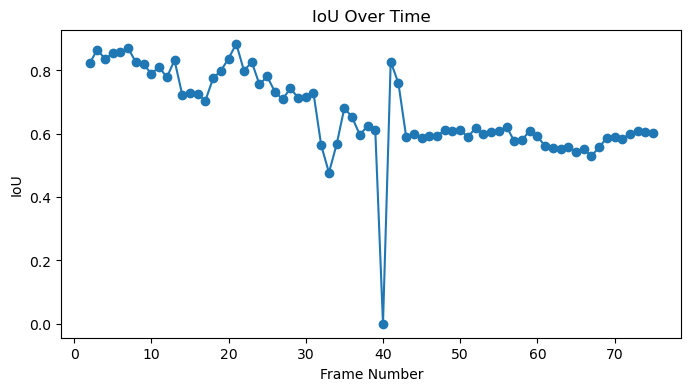

Sample frames:
High IoU:  0.8845724360208219
Low IoU:  0.0


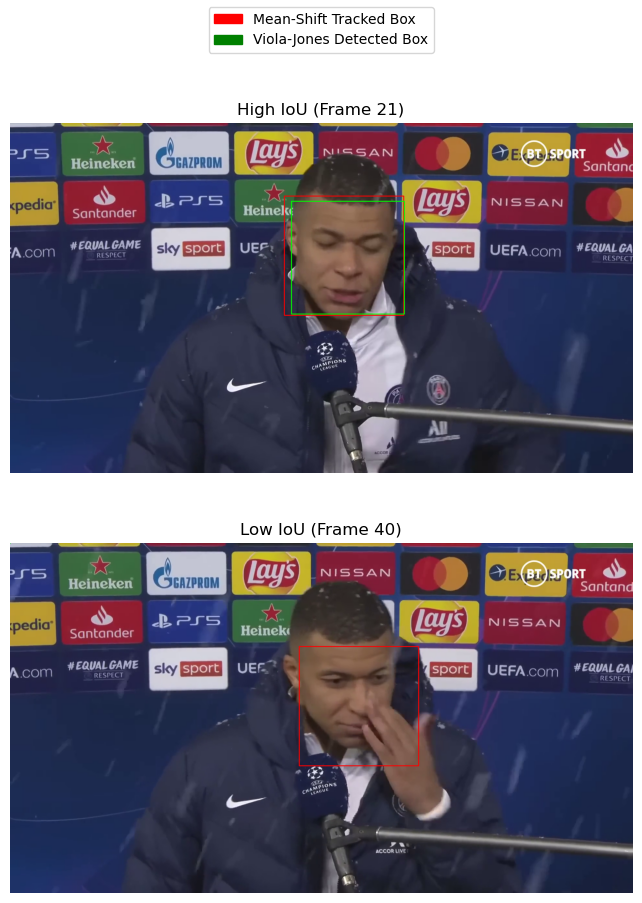

Percentage of frames with IoU > 50%: 97.30%


In [8]:
# IoU over time
print("IoU over time:")
plt.figure(figsize=(8,4))
plt.plot(frame_numbers, iou_list, marker='o')
plt.xlabel('Frame Number')
plt.ylabel('IoU')
plt.title('IoU Over Time')
plt.show()

# sample frames: Lowest vs Highest
print("Sample frames:")
fig = plt.figure(figsize=(10,10));
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
high_iou_idx = np.argmax(iou_list)
high_iou_img = cv2.cvtColor(annotated_frames[high_iou_idx], cv2.COLOR_BGR2RGB)
low_iou_idx = np.argmin(iou_list)
low_iou_img = cv2.cvtColor(annotated_frames[low_iou_idx], cv2.COLOR_BGR2RGB)
print("High IoU: ", iou_list[high_iou_idx])
print("Low IoU: ", iou_list[low_iou_idx])
ax1.imshow(high_iou_img)
ax2.imshow(low_iou_img)
ax1.axis('off');
ax2.axis('off');
ax1.set_title("High IoU (Frame {})".format(frame_numbers[high_iou_idx]))
ax2.set_title("Low IoU (Frame {})".format(frame_numbers[low_iou_idx]))
red_patch = patches.Patch(color='red', label='Mean-Shift Tracked Box')
green_patch = patches.Patch(color='green', label='Viola-Jones Detected Box')
fig.legend(handles=[red_patch, green_patch], loc='upper center');
plt.show()

# all frames:
# for img in annotated_frames:
#     iou_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     plt.figure(figsize=(8,4))
#     plt.imshow(iou_img)
#     plt.axis('off');

# percentage of frames in which the IoU is larger than 50%
num_high_iou = sum(1 for i in iou_list if i > 0.5)
percentage_high_iou = (num_high_iou / len(iou_list)) * 100
print("Percentage of frames with IoU > 50%: {:.2f}%".format(percentage_high_iou))


## 5.2 Implement a Simple Variation

### implementation:

In [9]:
cap = cv2.VideoCapture('KylianMbappe.mp4')
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# first frame
ret, frame = cap.read()
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray)
x, y, w, h = bounding_box(faces)
# ROI
roi = frame[y:y+h, x:x+w]
roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
roi_gray = cv2.GaussianBlur(roi_gray, (5, 5), 0)
# image gradients via Sobel
Ix = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
Iy = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)
mag, angle = cv2.cartToPolar(Ix, Iy, angleInDegrees=True)
# mask
max_mag = np.max(mag)
threshold = 0.015 * max_mag
###  np.uint8 was addapted from internet
mask = np.uint8((mag >= threshold) * 255)
# histogram (24 bins over [0,360])
roi_hist = cv2.calcHist([angle.astype(np.float32)], [0], mask, [24], [0, 360])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
track_window = (x, y, w, h)


# init
iou_list = []
frame_numbers = []
frame_id = 2  
annotated_frames = []
roi_threshold = threshold

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # grayscale, blur
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray_frame, (5, 5), 0)
    # gradients
    Ix_frame = cv2.Sobel(gray_blur, cv2.CV_64F, 1, 0, ksize=3)
    Iy_frame = cv2.Sobel(gray_blur, cv2.CV_64F, 0, 1, ksize=3)
    mag_frame, angle_frame = cv2.cartToPolar(Ix_frame, Iy_frame, angleInDegrees=True)
    # mask
    mask_frame = np.uint8((mag_frame >= roi_threshold) * 255)
    back_proj = cv2.calcBackProject([angle_frame.astype(np.float32)], [0], roi_hist, [0, 360], 1)
    back_proj = cv2.bitwise_and(back_proj, back_proj, mask=mask_frame)

    # Mean-Shift Tracking
    ret_val, track_window = cv2.meanShift(back_proj, track_window,
                                            (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1))
    tx, ty, tw, th = track_window

    # Viola-Jones Detection
    detected_faces = face_cascade.detectMultiScale(gray_frame)
    if len(detected_faces) == 0:
        dx, dy, dw, dh = 0, 0, 0, 0
    else:
        dx, dy, dw, dh = bounding_box(detected_faces)

    # IoU
    iou = compute_iou((tx, ty, tw, th), (dx, dy, dw, dh))
    iou_list.append(iou)
    frame_numbers.append(frame_id)

    # visualization
    annotated_frame = frame.copy()
    cv2.rectangle(annotated_frame, (tx, ty), (tx+tw, ty+th), (0, 0, 255), 2)
    cv2.rectangle(annotated_frame, (dx, dy), (dx+dw, dy+dh), (0, 255, 0), 2)
    annotated_frames.append(annotated_frame)
    frame_id += 1

cap.release()


## results:

IoU over time:


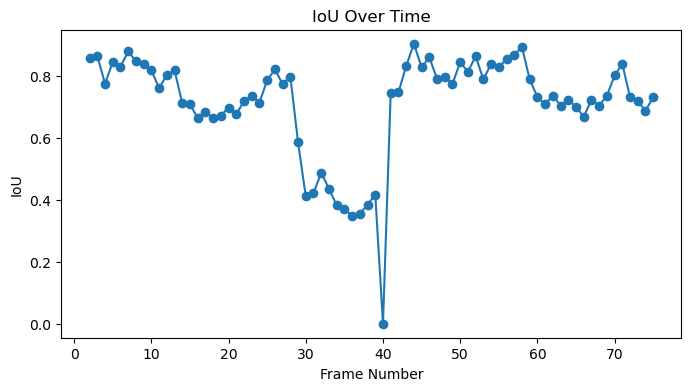

Sample frames:
High IoU:  0.9048057447317397
Low IoU:  0.38421870541558933


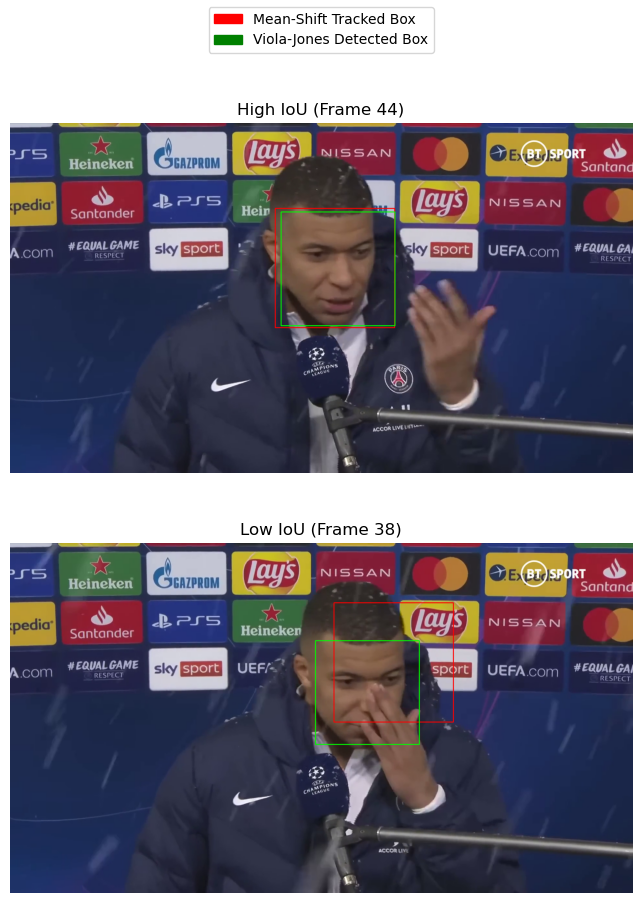

Percentage of frames with IoU > 50%: 85.14%


In [10]:
# IoU over time
print("IoU over time:")
plt.figure(figsize=(8,4))
plt.plot(frame_numbers, iou_list, marker='o')
plt.xlabel('Frame Number')
plt.ylabel('IoU')
plt.title('IoU Over Time')
plt.show()

# sample frames: Lowest vs Highest
print("Sample frames:")
fig = plt.figure(figsize=(10,10));
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
high_iou_idx = np.argmax(iou_list)
high_iou_img = cv2.cvtColor(annotated_frames[high_iou_idx], cv2.COLOR_BGR2RGB)
# hardcoded, non-zero IoU:
low_iou_idx = 36
# adapting, zero IoU:
# low_iou_idx = np.argmin(iou_list)
low_iou_img = cv2.cvtColor(annotated_frames[low_iou_idx], cv2.COLOR_BGR2RGB)
print("High IoU: ", iou_list[high_iou_idx])
print("Low IoU: ", iou_list[low_iou_idx])
ax1.imshow(high_iou_img)
ax2.imshow(low_iou_img)
ax1.axis('off');
ax2.axis('off');
ax1.set_title("High IoU (Frame {})".format(frame_numbers[high_iou_idx]))
ax2.set_title("Low IoU (Frame {})".format(frame_numbers[low_iou_idx]))
red_patch = patches.Patch(color='red', label='Mean-Shift Tracked Box')
green_patch = patches.Patch(color='green', label='Viola-Jones Detected Box')
fig.legend(handles=[red_patch, green_patch], loc='upper center');
plt.show()

# all frames:
# for img in annotated_frames:
#     iou_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     plt.figure(figsize=(8,4))
#     plt.imshow(iou_img)
#     plt.axis('off');

# percentage of frames in which the IoU is larger than 50%
num_high_iou = sum(1 for i in iou_list if i > 0.5)
percentage_high_iou = (num_high_iou / len(iou_list)) * 100
print("Percentage of frames with IoU > 50%: {:.2f}%".format(percentage_high_iou))
